In [1]:
# !pip install GraphST
# !pip install POT
# !pip install scikit-misc
# !pip3 install igraph
# !pip3 install leidenalg

In [2]:
import os
os.environ["R_HOME"] = "/opt/homebrew/Cellar/r/4.5.1/lib/R"
os.environ["DYLD_FALLBACK_LIBRARY_PATH"] = "/opt/homebrew/Cellar/r/4.5.1/lib"

In [3]:
import os
import torch
import pandas as pd
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp

/Users/jishar/Documents/SpaGCN/SpaGCN_package/spagcn_env/lib/python3.13/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [4]:
from GraphST import GraphST

In [5]:
# Run device, by default, the package is implemented on 'cpu'. We recommend using GPU.
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# the location of R, which is necessary for mclust algorithm. Please replace the path below with local R installation path
# os.environ['R_HOME'] = '/opt/homebrew/Cellar/r/4.5.1'

In [12]:
adata = sc.read_h5ad("../points2regions/data/Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_outs/Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_outs.h5ad")
adata.var_names_make_unique()

/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:929: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
# define model
model = GraphST.GraphST(adata, device=device)

# train model
adata = model.train()

In [ ]:
# adata = sc.read_h5ad("../celldega/notebooks/data/graphst_leiden_domains.h5ad")

In [ ]:
# # plotting spatial clustering result
# sc.pl.spatial(adata,
#               img_key="hires",
#               color=["domain"],
#               show=True)

In [6]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [7]:
# !pip install rpy2

In [8]:
import numpy as np
import rpy2.robjects as robjects
import GraphST.utils as gutils
from contextlib import contextmanager

def _patched_mclust_R(adata, num_cluster, modelNames="EEE", used_obsm="STAGATE", random_seed=2020):
    """
    Clean version of GraphST.utils.mclust_R that works with rpy2 3.5.x+
    (no activate/deactivate, no DeprecationWarnings).
    """
    np.random.seed(random_seed)
    robjects.r.library("mclust")
    r_random_seed = robjects.r["set.seed"]
    r_random_seed(random_seed)
    rmclust = robjects.r["Mclust"]

    # --- robust converter detection ---
    from rpy2.robjects import numpy2ri, conversion

    try:
        # modern >=3.5 API
        get_conv = getattr(conversion, "get_conversion", None)
        if get_conv is not None:
            base_converter = get_conv()
        elif hasattr(conversion, "converter"):  # newer 3.6+
            base_converter = conversion.converter
        else:
            raise AttributeError("no converter found")

        @contextmanager
        def numpy_conversion():
            with conversion.localconverter(base_converter + numpy2ri.converter):
                yield

        with numpy_conversion():
            res = rmclust(adata.obsm[used_obsm], num_cluster, modelNames)
            mclust_res = np.array(res[-2])

    except Exception:
        # last-resort fallback (older APIs)
        import warnings
        warnings.filterwarnings("ignore", category=DeprecationWarning)
        import rpy2.robjects.numpy2ri
        rpy2.robjects.numpy2ri.activate()
        res = rmclust(
            rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]),
            num_cluster,
            modelNames,
        )
        mclust_res = np.array(res[-2])

    adata.obs["mclust"] = pd.Series(
        mclust_res.astype(int),
        dtype="category",
        index=adata.obs.index
    )
    
    return adata


# Apply the patch
gutils.mclust_R = _patched_mclust_R
print("Patched GraphST.utils.mclust_R for rpy2 3.5.x (no warnings, stable).")

Error importing in API mode: ImportError("dlopen(/Users/jishar/Documents/SpaGCN/SpaGCN_package/spagcn_env/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/jishar/Documents/SpaGCN/SpaGCN_package/spagcn_env/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


Patched GraphST.utils.mclust_R for rpy2 3.5.x (no warnings, stable).


In [9]:
adata = sc.read_h5ad("../celldega/notebooks/data/graphst_mclust_domains.h5ad")

In [10]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area,region,leiden,domain,mclust
0,1,384,0,0,385,305.211094,70.714687,cell_circles,0,3,3
1,2,146,0,0,146,176.606094,6.412187,cell_circles,0,3,3
2,3,81,0,0,81,263.938281,32.783437,cell_circles,3,2,2
3,4,314,0,0,315,427.810313,68.185938,cell_circles,0,3,3
4,5,639,0,0,640,424.604219,102.956250,cell_circles,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...
36597,36598,352,0,0,352,466.960781,67.373125,cell_circles,9,6,6
36598,36599,412,1,0,413,576.193750,6.863750,cell_circles,9,6,6
36599,36600,161,0,0,161,398.323281,13.230781,cell_circles,9,6,6
36600,36601,387,0,0,387,510.762344,21.313750,cell_circles,9,6,6


In [11]:
# set radius to specify the number of neighbors considered during refinement
radius = 50
n_clusters = 20

tool = 'mclust' # mclust, leiden, and louvain

# clustering
from GraphST.utils import clustering

if tool == 'mclust':
   clustering(adata, n_clusters, radius=radius, method=tool, refinement=True) # For DLPFC dataset, we use optional refinement step.
elif tool in ['leiden', 'louvain']:
   clustering(adata, n_clusters, radius=radius, method=tool, start=0.1, end=2.0, increment=0.01, refinement=False)

R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.
  


fitting ...
  |======================================================================| 100%


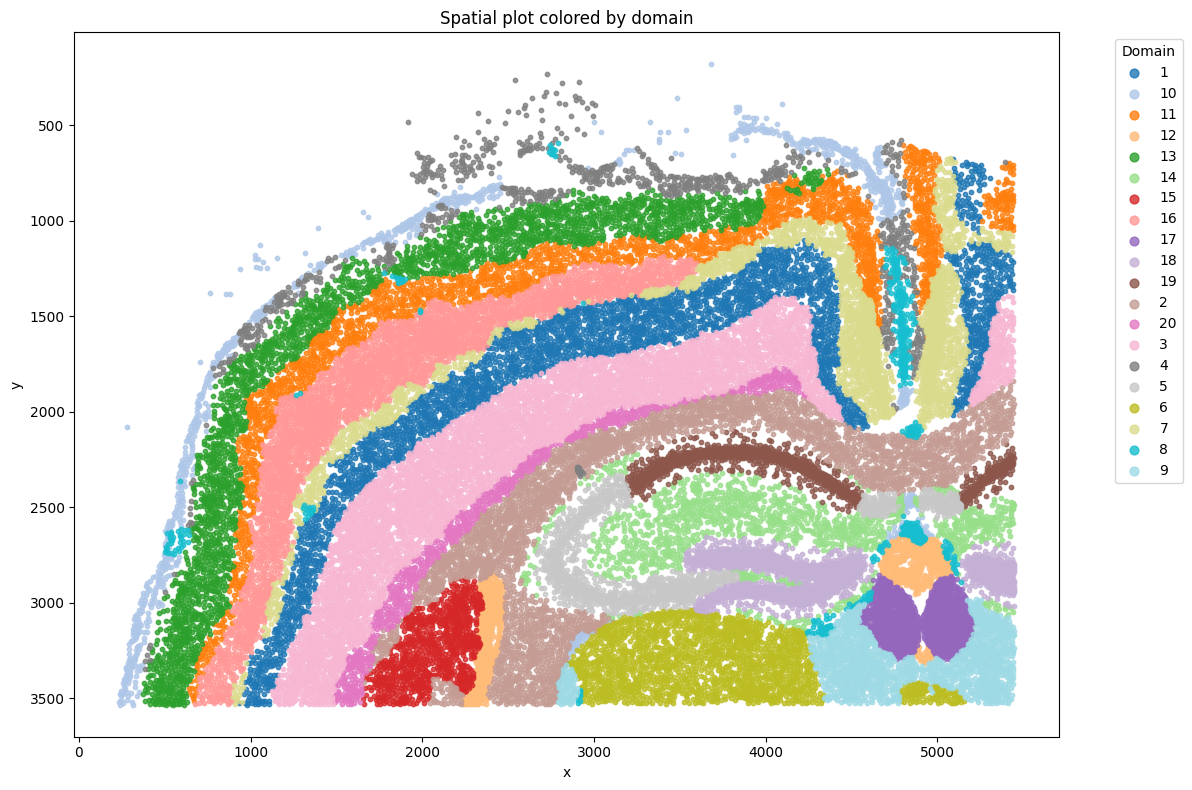

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Extract spatial coordinates and domain labels
coords = adata.obsm["spatial"]
domains = adata.obs["domain"]

# If domains are not categorical, make them so
domains = domains.astype("category")

# Define a categorical colormap (enough distinct colors)
cmap = plt.get_cmap("tab20", len(domains.cat.categories))

plt.figure(figsize=(12, 8))

# Scatter plot, colored by domain category
for i, cat in enumerate(domains.cat.categories):
    mask = domains == cat
    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        s=10,
        color=cmap(i),
        label=str(cat),
        alpha=0.8
    )

plt.legend(
    title="Domain",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    markerscale=2,
)
plt.title("Spatial plot colored by domain")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().invert_yaxis()  # spatial convention
plt.tight_layout()
plt.show()


In [13]:
# # plotting spatial clustering result
# sc.pl.spatial(adata,
#               img_key="hires",
#               color=["domain"],
#               show=True)

In [15]:
adata.write("graphst_mclust_20_domains.h5ad")